In [1]:
import geohexgrid as ghg
import numpy as np
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint, GeometryCollection
import geopandas as gpd
import pandas as pd
from math import comb
import numpy as np
import matplotlib.pyplot as plt
import collections
from typing import List, Tuple

## Get the shape of some city

  id                                     geometry
0  1  POLYGON ((0 0, 0 100, 100 100, 100 0, 0 0))


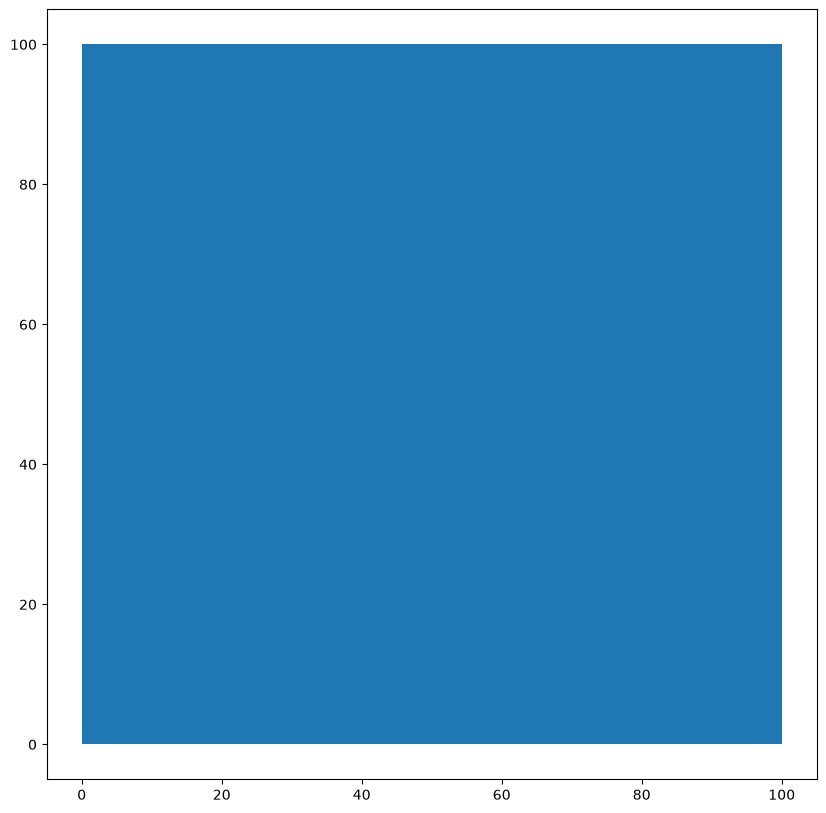

In [2]:
d = {'id': ['1'], 'geometry': [Polygon([(0., 0.), (0., 100.), (100., 100.), (100., 0.)])]}
base = gpd.GeoDataFrame(data=d, crs=None)
background = base.plot(figsize=(10, 10))
print(base)

## Create hex grid

<Axes: >

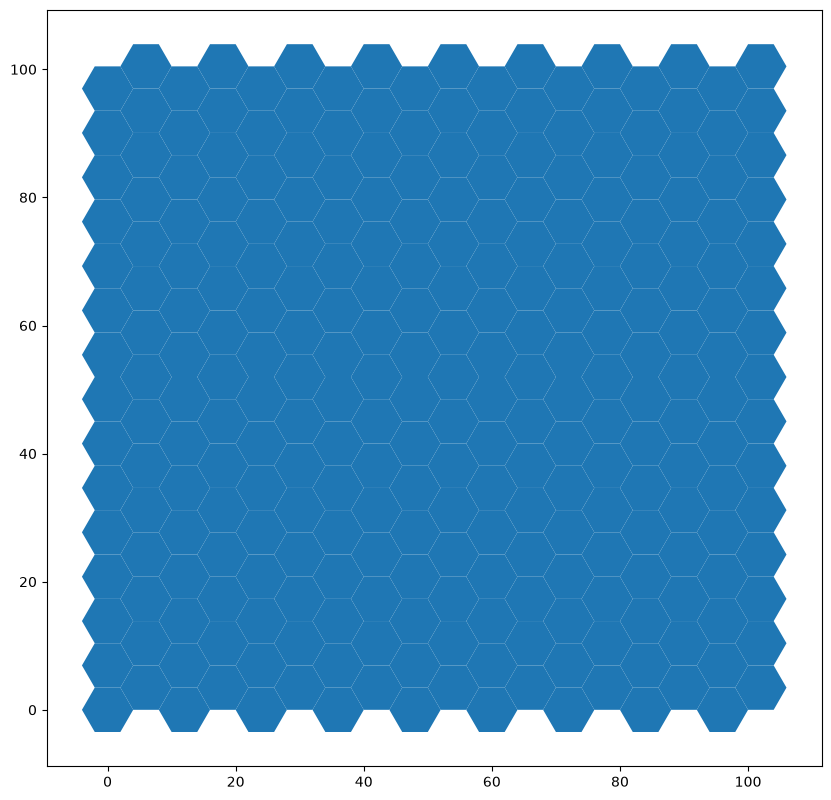

In [3]:
R = 4
grid = ghg.make_grid_from_bounds(0., 0., 100., 100., R)
grid.plot(figsize=(10, 10))

In [4]:
type(grid)

geopandas.geodataframe.GeoDataFrame

In [5]:
hex_example = grid.iat[0,-1]
hex_example
print(hex_example)

POLYGON ((-2 -3.4641016151377544, 2 -3.4641016151377544, 4 0, 2 3.4641016151377544, -2 3.4641016151377544, -4 0, -2 -3.4641016151377544))


In [6]:
print(f"area: {hex_example.area}")
print(f"boundary: {hex_example.boundary}")
print(f"bounds: {hex_example.bounds}")
print(f"centroid: {hex_example.centroid}")

area: 41.56921938165305
boundary: LINESTRING (-2 -3.4641016151377544, 2 -3.4641016151377544, 4 0, 2 3.4641016151377544, -2 3.4641016151377544, -4 0, -2 -3.4641016151377544)
bounds: (-4.0, -3.4641016151377544, 4.0, 3.4641016151377544)
centroid: POINT (5.697667218914264e-17 0)


## Extract seed points

In [7]:
grid['centroid'] = grid['geometry'].centroid
grid.head()

,cell_id,geometry,centroid
0,"0,0","POLYGON ((-2 -3.4641, 2 -3.4641, 4 0, 2 3.4641...",POINT (5.69767e-17 0)
1,"1,1","POLYGON ((4 0, 8 0, 10 3.4641, 8 6.9282, 4 6.9...",POINT (6 3.4641)
2,"2,0","POLYGON ((10 -3.4641, 14 -3.4641, 16 0, 14 3.4...",POINT (12 0)
3,"3,1","POLYGON ((16 0, 20 0, 22 3.4641, 20 6.9282, 16...",POINT (18 3.4641)
4,"4,0","POLYGON ((22 -3.4641, 26 -3.4641, 28 0, 26 3.4...",POINT (24 0)


<Axes: >

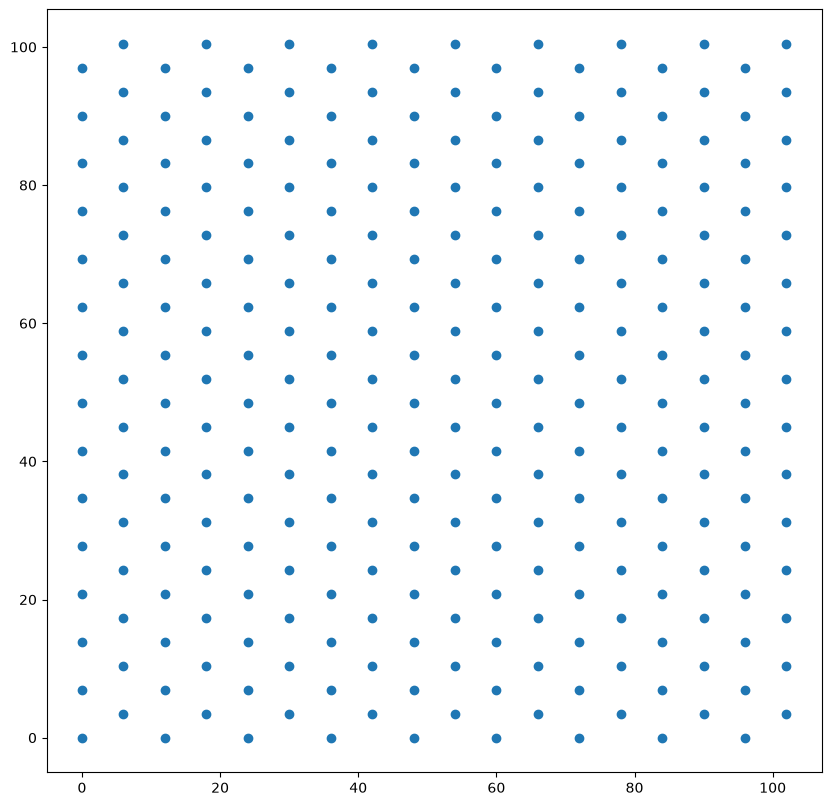

In [8]:
centroids = grid["centroid"]
centroids.plot(figsize=(10, 10))

## Create demand matrix

### Compute seed point pairs

no. of seed points: 270
no. of pairs is actually: 36315
no. of pairs should be: 36315


<Axes: >

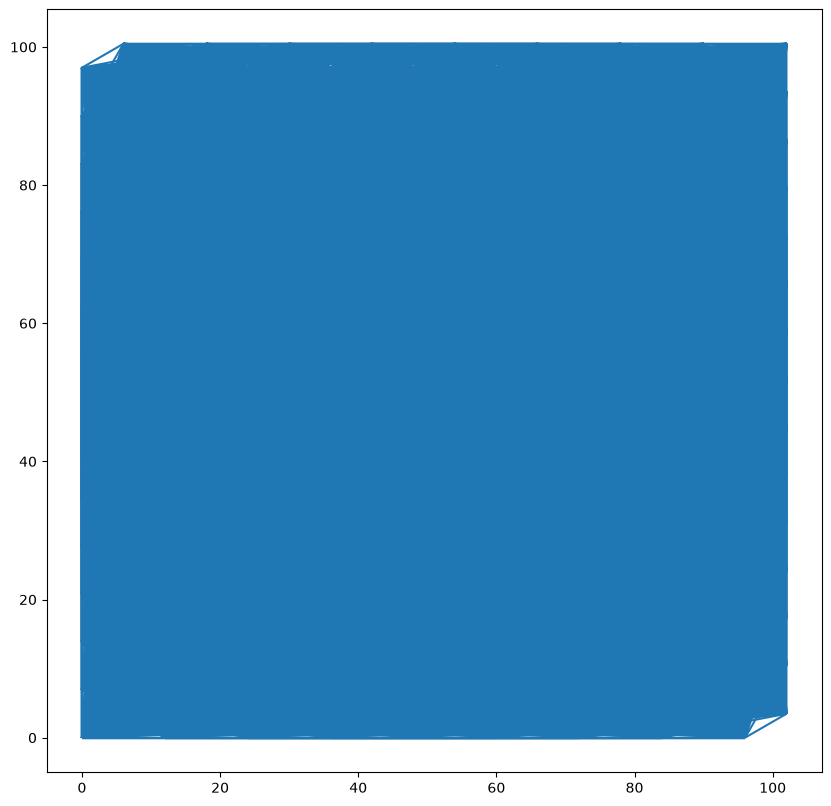

In [9]:
def od_pairs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    seed_points = gdf['cell_id'].values.tolist()
    geo = gdf['centroid'].values.tolist()
    n = len(seed_points)
    ids = []
    origins = []
    dests = []
    lines = []
    for i in range(n):
        for j in range(i+1, n):
            # print(f'seed_points[i]: {seed_points[i]}, seed_points[j]: {seed_points[j]}')
            # print(f'geo[i]: {geo[i]}, geo[j]: {geo[j]}')
            ids.append((seed_points[i], seed_points[j]))
            origins.append(seed_points[i])
            dests.append(seed_points[j])
            lines.append(LineString([geo[i], geo[j]]))
    return gpd.GeoDataFrame({'pair': ids, 'u': origins, 'v': dests, 'geometry': lines})

test_pairs = od_pairs(grid)
print(f'no. of seed points: {grid.shape[0]}')
print(f'no. of pairs is actually: {test_pairs.shape[0]}')
print(f'no. of pairs should be: {comb(grid.shape[0], 2)}')
test_pairs.head()
test_pairs.plot(figsize=(10, 10))

### Generate random demand

In [10]:
def generate_normal_demand(mean: float, std: float, n: int) -> np.ndarray:
    seed: int = 8920299146682435931
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    return rng.normal(mean, std, size=n)

# Code from NumPy docs
def plot_normal_demand_distribution(mean: float, std: float, demand: np.ndarray):
    count, bins, _ = plt.hist(demand, 30, density=True)
    plt.plot(bins, 1/(std * np.sqrt(2 * np.pi)) *
                   np.exp( - (bins - mean)**2 / (2 * std**2) ),
             linewidth=2, color='r')
    plt.show()

def generate_uniform_demand(n: int) -> np.ndarray:
    seed: int = 8920299146682435931
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    return rng.uniform(low=0.0, high=1.0, size=n)

def make_demand_weird(demand: np.ndarray) -> np.ndarray:
    seed: int = 8920299146682435931
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    n = len(demand)
    indices = [x for x in range(n)] 
    doubles = rng.choice(a=indices, size=int(n/4), replace=False)
    halves = rng.choice(a=indices, size=int(n/4), replace=False)
    for i in doubles:
        demand[i] = demand[i] * 2
    for i in halves:
        demand[i] = demand[i] / 1.5
    return demand

# Code from NumPy docs
def plot_demand_distribution(demand: np.ndarray):
    count, bins, _ = plt.hist(demand, 15, density=True)
    plt.plot(bins, np.ones_like(bins), linewidth=2, color='r')
    plt.show()

#TODO: MAKE THE DEMAND DISTRIBUTION WEIRD
#for report: demand could also be made proportional to popylation density. but for now this is our proxy 

In [11]:
P = test_pairs.shape[0] # number of seed point pairs
mean: float = 1.0
std: float = 0.2
test_demand = make_demand_weird(generate_uniform_demand(P))
print(type(test_demand))
print(len(test_demand))
print(len(test_demand))
test_demand

<class 'numpy.ndarray'>
36315
36315


array([0.89224646, 0.95848516, 0.77797029, ..., 0.36807494, 1.06773632,
       0.52107915], shape=(36315,))

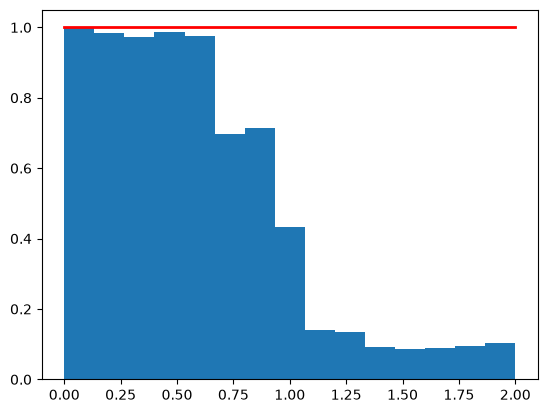

In [12]:
plot_demand_distribution(test_demand)

In [13]:
demand_matrix = pd.concat([test_pairs, pd.Series(test_demand)], axis=1)
demand_matrix.columns = ['pair', 'u', 'v', 'geometry', 'demand']
demand_matrix.head()
demand_matrix.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 36315 entries, 0 to 36314
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pair      36315 non-null  object  
 1   u         36315 non-null  str     
 2   v         36315 non-null  str     
 3   geometry  36315 non-null  geometry
 4   demand    36315 non-null  float64 
dtypes: float64(1), geometry(1), object(1), str(2)
memory usage: 1.7+ MB


In [14]:
ordered_demand = demand_matrix.sort_values(by=['demand', 'pair'], ascending=False)
ordered_demand.head()

,pair,u,v,geometry,demand
14479,"(6,6, 8,18)","6,6","8,18","LINESTRING (36 20.78461, 48 62.35383)",1.999475
30371,"(16,16, 14,22)","16,16","14,22","LINESTRING (96 55.42563, 84 76.21024)",1.997534
15572,"(11,7, 17,25)","11,7","17,25","LINESTRING (66 24.24871, 102 86.60254)",1.997330
7656,"(12,2, 16,4)","12,2","16,4","LINESTRING (72 6.9282, 96 13.85641)",1.996576
17268,"(2,8, 12,14)","2,8","12,14","LINESTRING (12 27.71281, 72 48.49742)",1.996458


## Calculate total demand

In [15]:
total_demand = float(demand_matrix['demand'].sum())
total_demand

20783.60282907067

In [16]:
demand_matrix["demand_share"] = demand_matrix["demand"] * 100 / total_demand

Text(0.5, 1.0, 'Seed point pairs')

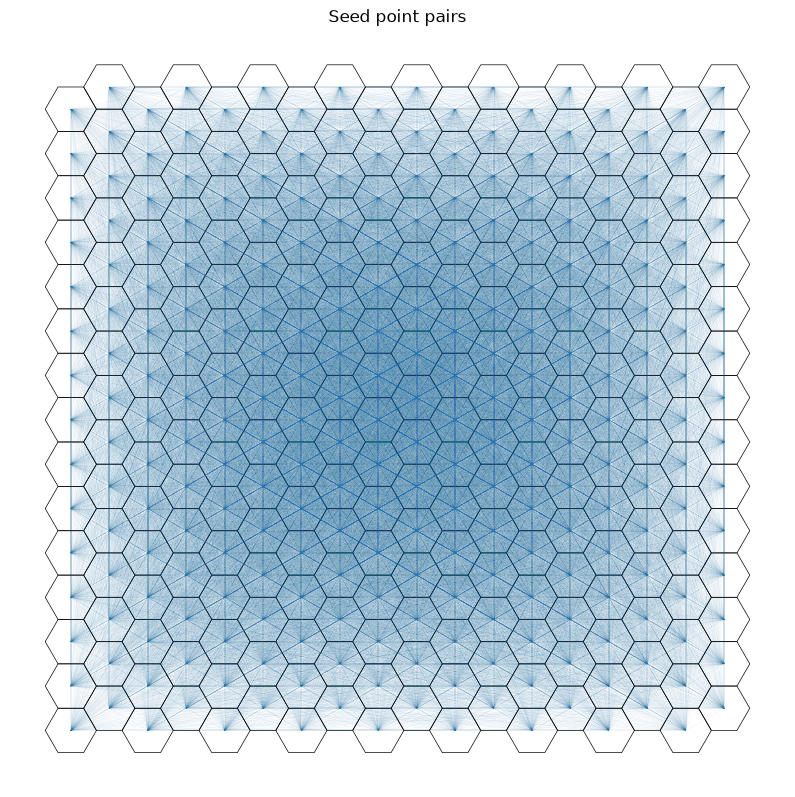

In [17]:
# With Anastassia's plot:

fig, ax = plt.subplots(1,1, figsize = (10,10))
grid.boundary.plot(ax=ax, color = "black", zorder = 0, lw = 0.5)
#grid.boundary.plot(column="centroid", ax=ax, alpha=0.5, color = "orange", label="seed points", markersize = 2, zorder = 1)
#test_pairs.plot(column='u', ax=ax, alpha=0.5, color = "blue", label = "origins", markersize = 2, zorder = 1)
#test_pairs.plot(column='v', ax=ax, alpha=0.5, color = "orange", label = "destinations", markersize = 2, zorder = 2)
demand_matrix.plot(ax=ax, lw = demand_matrix.demand_share * 20, alpha = 0.2)
ax.set_axis_off()
ax.set_title("Seed point pairs")


In [18]:
seed_points = grid
seed_points.columns = ['id', 'geometry', 'centroid']
seed_points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        270 non-null    str     
 1   geometry  270 non-null    geometry
 2   centroid  270 non-null    geometry
dtypes: geometry(2), str(1)
memory usage: 7.5 KB


In [19]:
seed_points["total_demand"] = seed_points.apply(
    lambda x:
        sum(demand_matrix[(demand_matrix.u == x.id) | (demand_matrix.v == x.id)].demand),
    axis = 1
)
seed_points.sort_values('total_demand', ascending=False).head()

,id,geometry,centroid,total_demand
108,"0,12","POLYGON ((-2 38.105, 2 38.105, 4 41.569, 2 45....",POINT (0 41.569),174.464674
84,"12,8","POLYGON ((70 24.249, 74 24.249, 76 27.713, 74 ...",POINT (72 27.713),171.553487
256,"4,28","POLYGON ((22 93.531, 26 93.531, 28 96.995, 26 ...",POINT (24 96.995),168.645258
102,"12,10","POLYGON ((70 31.177, 74 31.177, 76 34.641, 74 ...",POINT (72 34.641),167.148980
117,"9,13","POLYGON ((52 41.569, 56 41.569, 58 45.033, 56 ...",POINT (54 45.033),167.108650


Text(0.5, 1.0, 'Total demand per hexagon')

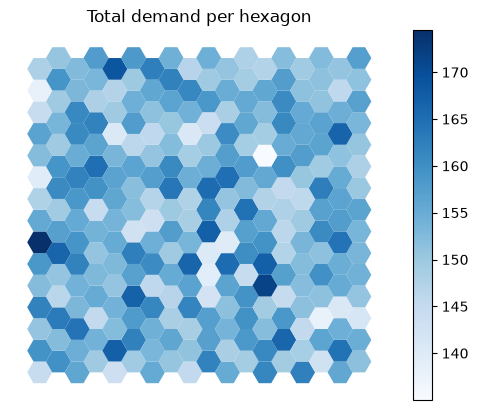

In [20]:

fig, ax = plt.subplots(1,1)
seed_points.plot(
    ax=ax,
    column="total_demand",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Total demand per hexagon")

## Genetic Algorithm

We currently have two dataframes we are working with: `seed_points` and `demand_matrix`

In [21]:
N: int = 100            # iterations
MAX_PATHS: int = 10
MAX_NODES: int = 15
SEED: int = 3581054352
RNG: np.random.Generator = np.random.default_rng(seed=SEED)

### Initial Route Set Generation

In [22]:
def numeric_id(s: str) -> Tuple[int, int]:
    x, y = s.split(",")
    return int(x), int(y)

def str_id(t: Tuple[int, int]) -> str:
    return f'{t[0]},{t[1]}'

#### Neighbour nodes and VNS

In [23]:
# Inspired by Red Blob Games

hex_directions = [
    (1, 0), (1, -1), (0, -1), 
    (-1, 0), (-1, 1), (0, 1)
]

def hex_direction(direction):
    return hex_directions[direction]

def hex_add(a, b):
    return a[0] + b[0], a[1] + b[1]

def hex_neighbour(hex, direction):
    return hex_add(hex, hex_direction(direction))

def axial_to_cube(q, r):
    s = -q-r
    return (q, r, s)

def cube_to_axial(q, r, s):
    assert not (round(q + r + s) != 0), "q + r + s must be 0"
    return (q, r)

def double_to_axial(node: Tuple[int, int]) -> Tuple[int, int]:
    u, v = node
    x, y = ghg.double_to_cartesian(u, v, R)
    return ghg.cartesian_to_axial(x, y, R)

# TODO: should only add neighbours to vns if they are in the dataset, i.e. within the bounding box
def vns(node: Tuple[int, int]) -> List[Tuple[int, int]]:
    q, r = double_to_axial(node)
    vns = []
    for i in range(6):
        a, b = hex_neighbour((q, r), i)
        neighbour = ghg.axial_to_double(a, b)
        vns.append(str_id(neighbour))
    return vns

# SPATIAL INDEXING IN GEOPANDAS. STH WITH TREES

In [24]:
# Place neighbour nodes in Vicinity Node Set
seed_points["vns"] = seed_points["id"].apply(lambda s: vns(numeric_id(s)))
seed_points.head()

,id,geometry,centroid,total_demand,vns
0,"0,0","POLYGON ((-2 -3.4641, 2 -3.4641, 4 0, 2 3.4641...",POINT (5.69767e-17 0),144.630881,"[1,1, 1,-1, 0,-2, -1,-1, -1,1, 0,2]"
1,"1,1","POLYGON ((4 0, 8 0, 10 3.4641, 8 6.9282, 4 6.9...",POINT (6 3.4641),159.760828,"[2,2, 2,0, 1,-1, 0,0, 0,2, 1,3]"
2,"2,0","POLYGON ((10 -3.4641, 14 -3.4641, 16 0, 14 3.4...",POINT (12 0),156.240549,"[3,1, 3,-1, 2,-2, 1,-1, 1,1, 2,2]"
3,"3,1","POLYGON ((16 0, 20 0, 22 3.4641, 20 6.9282, 16...",POINT (18 3.4641),149.703474,"[4,2, 4,0, 3,-1, 2,0, 2,2, 3,3]"
4,"4,0","POLYGON ((22 -3.4641, 26 -3.4641, 28 0, 26 3.4...",POINT (24 0),143.611325,"[5,1, 5,-1, 4,-2, 3,-1, 3,1, 4,2]"


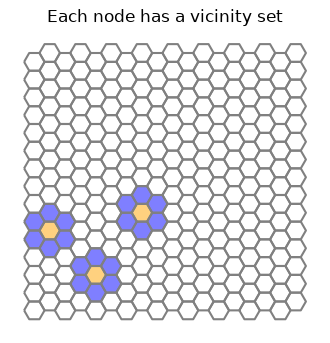

In [25]:
# Anastassia's code for VNS plot
fig, ax = plt.subplots(1,1, figsize = (4,4))
seed_points.boundary.plot(ax=ax, color = "grey")
for i in ['7,11', '4,4', '1,9']:
    seed_points[seed_points.id==i].plot(ax=ax, color = "orange", alpha = 0.5)
    seed_points[seed_points.id.isin(seed_points.loc[seed_points.id==i, "vns"].values[0])].plot(ax=ax, color = "blue", alpha = 0.5)
ax.set_axis_off()
ax.set_title("Each node has a vicinity set")
plt.show()

#### Create starting network (Initial Route Set)

In [26]:
def normalise_probabilities(df):
    p = df.to_numpy(dtype=np.float64)
    return p / np.sum(p, dtype=np.float64)

# TODO: bias terms for each node in the VNS?
# TODO: needs some way to stop if no node in VNS is possible. boolean in irs dict?
def next_node(p: int, previous_node: str, irs: dict):
    # Calculate probabilities for each node in the VNS
    filter = seed_points.loc[seed_points['id'] == previous_node, ['vns']].values.tolist()[0][0]
    vns = seed_points.loc[seed_points['id'].isin(filter)].sort_values(by=['total_demand'], ascending=False)
    activity_sum = float(vns['total_demand'].sum()) 
    vns['probability'] = vns['total_demand'] / activity_sum
    #print(vns['probability'].sum())
    #vns['probability'] = vns['probability'] / np.sum(vns['probability'], dtype=np.float64) # normalise, see: https://stackoverflow.com/questions/46539431/np-random-choice-probabilities-do-not-sum-to-1
    #print(vns['probability'].sum())

    # Select next node and add to dict
    tries = vns.shape[0]
    next_node = ''
    for _ in range(tries):
        next_node = RNG.choice(a=vns['id'], p=normalise_probabilities(vns['probability']))
        if next_node not in irs[p]['nodes']:
            #print(type(irs[p]['nodes']))
            #print(irs[p]['nodes']) 
            irs[p]['nodes'].append(next_node)
            break
        else:
            vns = vns[(vns['id'] != next_node)]
    finished = vns.shape[0] == 0 # stop if no node in VNS is possible
    return (next_node, irs, finished)

def generate_route(k: int):
    """
    Form Initial Node Set (INS) from the first k nodes. k must be larger than MAX_PATHS
    """
    irs = {}
    ins = seed_points.copy().sort_values("total_demand", ascending=False).head(k).reset_index(drop=True)

    # Select first nodes
    for i in range(MAX_PATHS):
        # Calculate probabilities of selection a node j as first node
        activity_sum = float(ins['total_demand'].sum())
        ins['probability'] = ins['total_demand'] / activity_sum
        #ins['probability'] /= ins['probability'].sum() # normalise, see: https://stackoverflow.com/questions/46539431/np-random-choice-probabilities-do-not-sum-to-1
    
        # Select first node
        first_node = RNG.choice(a=ins['id'], p=normalise_probabilities(ins['probability']))
    
        # Add to dict
        #u, v = numeric_id(first_node)
        irs[i] = {'nodes': [first_node]}
    
        # Remove selected node from INS
        ins = ins[(ins['id'] != first_node)]

        # Build paths
        previous_node = first_node
        for _ in range(MAX_NODES-1): # -1 because we already added first_node
            tmp_next, tmp_irs, finished = next_node(i, previous_node, irs)
            if finished: # stop if no node in VNS is possible
                break
            previous_node = tmp_next
            irs = tmp_irs

    return irs

In [27]:
k = int(len(seed_points)/2) # how many start nodes do we initialize our routes with
irs = generate_route(k)
irs

{0: {'nodes': ['14,0',
   '13,1',
   '12,2',
   '13,3',
   '13,5',
   '14,4',
   '14,2',
   '15,1',
   '16,0',
   '17,1',
   '17,3',
   '16,2',
   '15,3',
   '15,5',
   '15,7']},
 1: {'nodes': ['9,13',
   '9,11',
   '10,10',
   '10,8',
   '11,9',
   '12,8',
   '12,6',
   '11,7',
   '11,5',
   '10,6',
   '9,7',
   '9,5',
   '9,3',
   '9,1',
   '10,2']},
 2: {'nodes': ['16,22',
   '16,20',
   '15,19',
   '15,17',
   '16,18',
   '17,19',
   '17,21',
   '17,23',
   '16,24',
   '15,25',
   '14,26',
   '14,24',
   '15,23',
   '15,21',
   '14,22']},
 3: {'nodes': ['2,2',
   '1,1',
   '0,0',
   '0,2',
   '1,3',
   '2,4',
   '2,6',
   '3,7',
   '3,5',
   '4,6',
   '4,4',
   '4,2',
   '5,3',
   '5,5',
   '6,4']},
 4: {'nodes': ['6,4',
   '7,5',
   '7,7',
   '6,6',
   '5,5',
   '5,7',
   '4,6',
   '4,8',
   '5,9',
   '6,10',
   '7,11',
   '6,12',
   '5,13',
   '4,14',
   '3,15']},
 5: {'nodes': ['14,22',
   '14,24',
   '15,25',
   '16,26',
   '17,25',
   '17,27',
   '16,28',
   '15,27',
   '14,28

In [28]:
id_to_centroid = seed_points.set_index("id")["centroid"]
id_to_centroid

id
0,0      POINT (5.698e-17 0)
1,1          POINT (6 3.464)
2,0             POINT (12 0)
3,1         POINT (18 3.464)
4,0             POINT (24 0)
                ...         
13,29     POINT (78 100.459)
14,28      POINT (84 96.995)
15,29     POINT (90 100.459)
16,28      POINT (96 96.995)
17,29    POINT (102 100.459)
Name: centroid, Length: 270, dtype: geometry

In [29]:
# Create dict for network
d = {
    'path_id': [path_id for path_id in irs],
    'start_id': [path.get('nodes')[:][0] for _, path in irs.items()],
    'end_id': [path.get('nodes')[:][-1] for _, path in irs.items()],
    'path': [path.get('nodes') for _, path in irs.items()],
    #'demand_covered': [],
    #'geometry': []
}

# Flatten list of paths to list of seed points
points = [
    point
    for path in d['path']
    for point in path
]

# TODO: Calculate covered demand


# Create geometries
id_to_centroid = seed_points.set_index("id")["centroid"].to_dict()
geom = [
    LineString([id_to_centroid[point_id] for point_id in path])
    for path in d['path']
]

# Create dataframe
initial_network = gpd.GeoDataFrame(d, geometry=geom, crs=None)

initial_network

,path_id,start_id,end_id,path,geometry
0,0,"14,0","15,7","[14,0, 13,1, 12,2, 13,3, 13,5, 14,4, 14,2, 15,...","LINESTRING (84 0, 78 3.464, 72 6.928, 78 10.39..."
1,1,"9,13","10,2","[9,13, 9,11, 10,10, 10,8, 11,9, 12,8, 12,6, 11...","LINESTRING (54 45.033, 54 38.105, 60 34.641, 6..."
2,2,"16,22","14,22","[16,22, 16,20, 15,19, 15,17, 16,18, 17,19, 17,...","LINESTRING (96 76.21, 96 69.282, 90 65.818, 90..."
3,3,"2,2","6,4","[2,2, 1,1, 0,0, 0,2, 1,3, 2,4, 2,6, 3,7, 3,5, ...","LINESTRING (12 6.928, 6 3.464, 5.698e-17 0, -5..."
4,4,"6,4","3,15","[6,4, 7,5, 7,7, 6,6, 5,5, 5,7, 4,6, 4,8, 5,9, ...","LINESTRING (36 13.856, 42 17.321, 42 24.249, 3..."
5,5,"14,22","10,28","[14,22, 14,24, 15,25, 16,26, 17,25, 17,27, 16,...","LINESTRING (84 76.21, 84 83.138, 90 86.603, 96..."
6,6,"2,24","3,19","[2,24, 3,23, 3,25, 4,26, 3,27, 2,28, 1,27, 2,2...","LINESTRING (12 83.138, 18 79.674, 18 86.603, 2..."
7,7,"1,1","0,0","[1,1, 1,3, 0,2, 0,0]","LINESTRING (6 3.464, 6 10.392, -5.698e-17 6.92..."
8,8,"16,10","14,16","[16,10, 16,12, 17,11, 17,9, 17,7, 16,8, 15,9, ...","LINESTRING (96 34.641, 96 41.569, 102 38.105, ..."
9,9,"9,29","15,21","[9,29, 9,27, 10,28, 10,26, 10,24, 11,25, 12,26...","LINESTRING (54 100.459, 54 93.531, 60 96.995, ..."


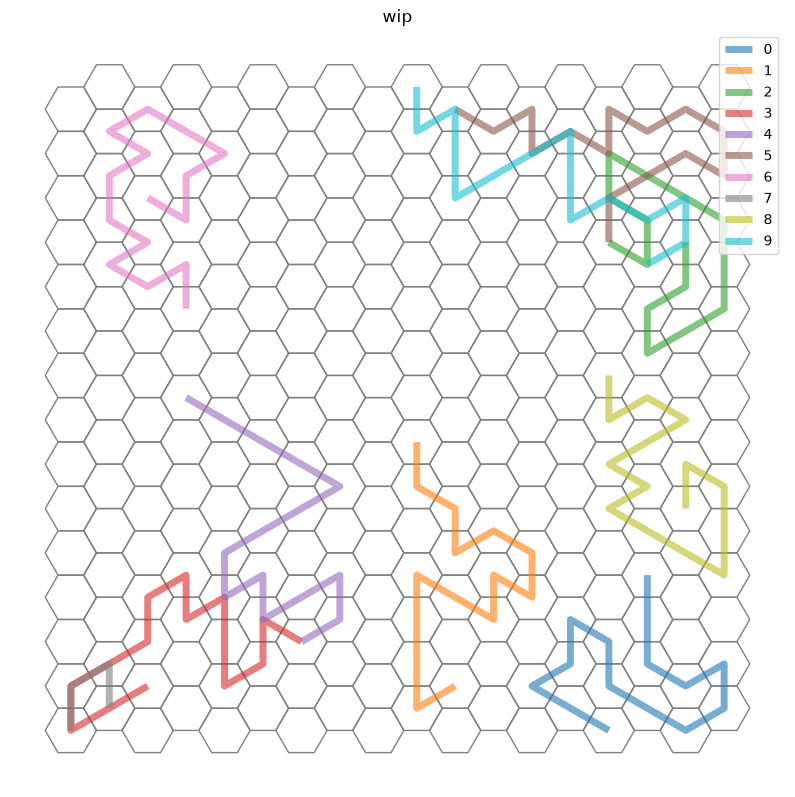

In [34]:
import matplotlib as mpl

cmap = mpl.colormaps.get_cmap('tab10')
colors = cmap(np.linspace(0, 1, len(initial_network)))

fig, ax = plt.subplots(1,1, figsize=(10,10))
#start_nodes.plot(ax=ax, alpha = .1)
seed_points.boundary.plot(ax=ax, color = "grey", lw = 1)
#grid_centroids.plot(ax=ax, color = "black", markersize=1)
for path_id in initial_network['path_id']:
    initial_network[initial_network['path_id']==path_id].plot(
        ax=ax,
        lw=5,
        alpha = 0.6,
        label=path_id,
        color=colors[path_id])
ax.legend()
ax.set_title("wip")
ax.set_axis_off()
plt.show()

In [31]:
print(seed_points.info())
seed_points.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id            270 non-null    str     
 1   geometry      270 non-null    geometry
 2   centroid      270 non-null    geometry
 3   total_demand  270 non-null    float64 
 4   vns           270 non-null    object  
dtypes: float64(1), geometry(2), object(1), str(1)
memory usage: 11.8+ KB
None


,id,geometry,centroid,total_demand,vns
0,"0,0","POLYGON ((-2 -3.4641, 2 -3.4641, 4 0, 2 3.4641...",POINT (5.69767e-17 0),144.630881,"[1,1, 1,-1, 0,-2, -1,-1, -1,1, 0,2]"
1,"1,1","POLYGON ((4 0, 8 0, 10 3.4641, 8 6.9282, 4 6.9...",POINT (6 3.4641),159.760828,"[2,2, 2,0, 1,-1, 0,0, 0,2, 1,3]"
2,"2,0","POLYGON ((10 -3.4641, 14 -3.4641, 16 0, 14 3.4...",POINT (12 0),156.240549,"[3,1, 3,-1, 2,-2, 1,-1, 1,1, 2,2]"
3,"3,1","POLYGON ((16 0, 20 0, 22 3.4641, 20 6.9282, 16...",POINT (18 3.4641),149.703474,"[4,2, 4,0, 3,-1, 2,0, 2,2, 3,3]"
4,"4,0","POLYGON ((22 -3.4641, 26 -3.4641, 28 0, 26 3.4...",POINT (24 0),143.611325,"[5,1, 5,-1, 4,-2, 3,-1, 3,1, 4,2]"


In [32]:
print(demand_matrix.info())
demand_matrix.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 36315 entries, 0 to 36314
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   pair          36315 non-null  object  
 1   u             36315 non-null  str     
 2   v             36315 non-null  str     
 3   geometry      36315 non-null  geometry
 4   demand        36315 non-null  float64 
 5   demand_share  36315 non-null  float64 
dtypes: float64(2), geometry(1), object(1), str(2)
memory usage: 1.9+ MB
None


,pair,u,v,geometry,demand,demand_share
0,"(0,0, 1,1)","0,0","1,1","LINESTRING (5.69767e-17 0, 6 3.4641)",0.892246,0.004293
1,"(0,0, 2,0)","0,0","2,0","LINESTRING (5.69767e-17 0, 12 0)",0.958485,0.004612
2,"(0,0, 3,1)","0,0","3,1","LINESTRING (5.69767e-17 0, 18 3.4641)",0.777970,0.003743
3,"(0,0, 4,0)","0,0","4,0","LINESTRING (5.69767e-17 0, 24 0)",1.252564,0.006027
4,"(0,0, 5,1)","0,0","5,1","LINESTRING (5.69767e-17 0, 30 3.4641)",1.561905,0.007515


In [33]:
from typing import Dict, List, Tuple

# Gene: a path consisting of several edges
# Chromosome: a candidate solution (i.e. a network) consisting of genes
# Population: a collection of candidate solutions
# Generation: the population in a given iteration of the genetic algorithm

### TYPE ALIASES ###

type EdgeList = list[Tuple[int, int]]
type Gene = list[int] # the ints map to bit indexes in a chromosome
type Chromosome = int # each bit is an edge, identified by its bit index in the int
type Population = dict[Chromosome, float] # float for fitness function

### MAIN ###

def run(edges: EdgeList, demand: List[float], iterations: int) -> EdgeList:
    N = len(edges)
    total_demand = sum(demand)
    return _genetic_algorithm(iterations, N, demand, total_demand)
    # should the last population be returned to the user, or something else?

### VISUALISATION ##

def plot_network():
    """
    Visualises a chromosome as a network, including the percentage of demand covered.
    """

def plot_generation():
    """
    Creates a scatter plot of a generation, where each blob is a chromosome (network),
    the x axis is the total length of the network, and the y axis is the percentage of
    total demand covered.
    """

### ORCHESTRATOR ###

def _genetic_algorithm(iterations: int, N: int, demand: List[float], total_demand: float) -> Population:
    population = _initialise(N)
    for i in range(iterations): # or until some other convergence criteria
        evaluated = _evaluation(N, population, demand, total_demand)
        parents = _selection(evaluated)
        children = _evolution(parents)
        plot_generation(children)
        #_log_generation(children)
        population = children
    return population

### KEY FUNCTIONS ###

def _initialise(N: int) -> Population:
    """
    Generate a random selection of chromosomes for the first generation.
    """

def _evaluation(N: int, pop: Population, demand: List[float], total_demand: float) -> Population:
    """
    Calculates the percentage of demand covered for each chromosome in the population.
    """
    for c in pop:
        pop[c] = (fitness(N, c, demand) * 100) / total_demand
    return pop

def _selection():
    """
    Select parent chromosomes to breed the next generation, based on some survival probability.
    """

def _crossover():
    """
    Swap genes (sequences of edges) between parent chromosomes to create two child chromosomes.

    For each parent pair (inspired by Mesbah 2012):
    1. Assume that each parent is a connected network
    2. Determine shared vertices (edges) between the parents
    3. Randomly choose 1 shared vertex*
    4. Swap all edges that precede the selected shared vertex
    5. This produces 2 child solutions that are both connected

    *if no shared vertex exists, this parent pair doesn't produce new child solutions
    """

def _mutation():
    """
    Randomly add, remove or replace an edge

    For each ??? (inspired by Mesbah 2012):
    1. Determine the possible edge additions and removals that ensure connectedness
    2. Randomly choose 1 action from [add|remove|replace]
    3. Randomly choose 1 edge (from possible choices in step 1) to [add|remove|replace]
    """

def _evolution():
    """
    Create the next population.
    """

### HELPERS ###

def fitness(N: int, chromosome: Chromosome, demand: List[float]) -> float:
    acc_demand = 0.0
    for i in range(N):
        if edge_included(i, chromosome):
            acc_demand += demand[i]
    return acc_demand

def edge_included(pos: int, num: int) -> bool:
    mask = 1 << pos
    return (num & mask) != 0

def _mutate():
    """
    Randomly add, remove or replace an edge 
    """

def _reproduce():

#def _log_generation():

_IncompleteInputError: incomplete input (1250370299.py, line 119)